### Loading the dataset
This is the newly feature engineered dataset from `feature_engineering.ipynb`

In [1]:
import pandas as pd
import numpy as np

# loading the dataset into dataframe
df = pd.read_csv('../data/features_rolling.csv')

df.head()

,timestamp,server_id,cpu_percent,memory_percent,disk_io,is_anomaly,anomaly_type,cpu_percent_roll_mean_5,cpu_percent_roll_standard_deviation_5,cpu_percent_roll_mean_10,...,hour,day_of_week,cpu_percent_rate_of_change,memory_percent_rate_of_change,disk_io_rate_of_change,server_type_batch_worker,server_type_cache,server_type_database,server_type_load_balancer,server_type_web
0,2025-01-01 00:10:00,web_1,29.583721,35.496424,45.627445,0,normal,25.765965,1.669845,25.765965,...,0,2,2.636997,-1.633358,-3.262710,0,0,0,0,1
1,2025-01-01 00:15:00,web_1,24.330454,30.116072,50.508945,0,normal,27.038551,2.500522,27.038551,...,0,2,-5.253267,-5.380352,4.881500,0,0,0,0,1
2,2025-01-01 00:20:00,web_1,24.356086,32.283149,47.617581,0,normal,26.361526,2.449868,26.361526,...,0,2,0.025633,2.167077,-2.891364,0,0,0,0,1
3,2025-01-01 00:25:00,web_1,29.829008,34.611279,45.449479,0,normal,25.960438,2.303421,25.960438,...,0,2,5.472921,2.328130,-2.168102,0,0,0,0,1
4,2025-01-01 00:30:00,web_1,27.433818,38.424553,47.917807,0,normal,27.009198,2.683192,26.605200,...,0,2,-2.395189,3.813275,2.468328,0,0,0,0,1


### Dropping columns 
Dropping the following:
- `timestamp`: raw datetime, not usuable
- `server_id`: just use the lable or identifier

### Training the model using Isolation forest: full 39 feature set
Split the dataframe for **training** and **testing**, and create a **normal** dataframe removing anomalies. This done so the model can see what the normal metrics look like and efficently test if it can detect anomalies

In [2]:
# Splitting the dataframe into testing and training sets
train_df = df[df['timestamp'] < '2025-01-15 00:00:00']
test_df = df[df['timestamp'] >= '2025-01-15 00:00:00']

# generate a baseline df, where there are no anomalies for training the model
normal_train_df = train_df[train_df['is_anomaly'] == 0]

print(len(train_df))
print(len(test_df))
print(len(normal_train_df))

print(train_df['is_anomaly'].value_counts())
print(test_df['is_anomaly'].value_counts())
print(normal_train_df['is_anomaly'].value_counts())

60450
120960
60382
is_anomaly
0    60382
1       68
Name: count, dtype: int64
is_anomaly
0    120859
1       101
Name: count, dtype: int64
is_anomaly
0    60382
Name: count, dtype: int64


In [3]:
# train set
y_train = normal_train_df['is_anomaly']
# `is_anomaly`: this is the ground truth label, and shoulnd't be used during training
X_train = normal_train_df.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

print(X_train.shape)
print(X_train.columns)
print(y_train.value_counts())

(60382, 40)
Index(['cpu_percent', 'memory_percent', 'disk_io', 'cpu_percent_roll_mean_5',
       'cpu_percent_roll_standard_deviation_5', 'cpu_percent_roll_mean_10',
       'cpu_percent_roll_standard_deviation_10', 'cpu_percent_roll_mean_30',
       'cpu_percent_roll_standard_deviation_30', 'memory_percent_roll_mean_5',
       'memory_percent_roll_standard_deviation_5',
       'memory_percent_roll_mean_10',
       'memory_percent_roll_standard_deviation_10',
       'memory_percent_roll_mean_30',
       'memory_percent_roll_standard_deviation_30', 'disk_io_roll_mean_5',
       'disk_io_roll_standard_deviation_5', 'disk_io_roll_mean_10',
       'disk_io_roll_standard_deviation_10', 'disk_io_roll_mean_30',
       'disk_io_roll_standard_deviation_30', 'cpu_percent_zscore_5',
       'cpu_percent_zscore_10', 'cpu_percent_zscore_30',
       'memory_percent_zscore_5', 'memory_percent_zscore_10',
       'memory_percent_zscore_30', 'disk_io_zscore_5', 'disk_io_zscore_10',
       'disk_io_zscore_

In [4]:
# test set
y_test = test_df['is_anomaly']
X_test = test_df.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

print(X_test.shape)
print(X_test.columns)
print(y_test.value_counts())

(120960, 40)
Index(['cpu_percent', 'memory_percent', 'disk_io', 'cpu_percent_roll_mean_5',
       'cpu_percent_roll_standard_deviation_5', 'cpu_percent_roll_mean_10',
       'cpu_percent_roll_standard_deviation_10', 'cpu_percent_roll_mean_30',
       'cpu_percent_roll_standard_deviation_30', 'memory_percent_roll_mean_5',
       'memory_percent_roll_standard_deviation_5',
       'memory_percent_roll_mean_10',
       'memory_percent_roll_standard_deviation_10',
       'memory_percent_roll_mean_30',
       'memory_percent_roll_standard_deviation_30', 'disk_io_roll_mean_5',
       'disk_io_roll_standard_deviation_5', 'disk_io_roll_mean_10',
       'disk_io_roll_standard_deviation_10', 'disk_io_roll_mean_30',
       'disk_io_roll_standard_deviation_30', 'cpu_percent_zscore_5',
       'cpu_percent_zscore_10', 'cpu_percent_zscore_30',
       'memory_percent_zscore_5', 'memory_percent_zscore_10',
       'memory_percent_zscore_30', 'disk_io_zscore_5', 'disk_io_zscore_10',
       'disk_io_zscore

In [5]:
# calculate the contamination rate 
contamination_rate = y_train.sum() / len(y_train)
print(contamination_rate)

0.0


In [6]:
# fit the model with the dataframe
from sklearn.ensemble import IsolationForest
clf = IsolationForest(contamination='auto',random_state=42).fit(X_train)

In [7]:
predictions = clf.predict(X_test)
print(pd.Series(predictions).value_counts())

 1    103402
-1     17558
Name: count, dtype: int64


### Classification report 
`Precision` - How many of the true positves flagged by the model is accurate 
$$Precision = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$
`Recall` - How many actually true positives did the model catch 
$$Recall = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$
`F1-score1` - This is the harmonic mean of the recall and precison
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The precison, recall and f1-score (for this first round of training the model) for class `1` is extremley low, meaning the model is not catching anything almost correctly.

In [8]:
# check the models predictions
from sklearn.metrics import classification_report

# if predictions == -1, this would output True
# .astype will convert True to 1
predictions_binary = (predictions == -1).astype(int) # converts -1 to 1

# classification report on the predicitons
classification_report_full_set = classification_report(y_test, predictions_binary)
print(classification_report_full_set)

              precision    recall  f1-score   support

           0       1.00      0.86      0.92    120859
           1       0.01      0.90      0.01       101

    accuracy                           0.86    120960
   macro avg       0.50      0.88      0.47    120960
weighted avg       1.00      0.86      0.92    120960



#### Confusion matrix

col_0            0      1
is_anomaly               
0           103392  17467
1               10     91


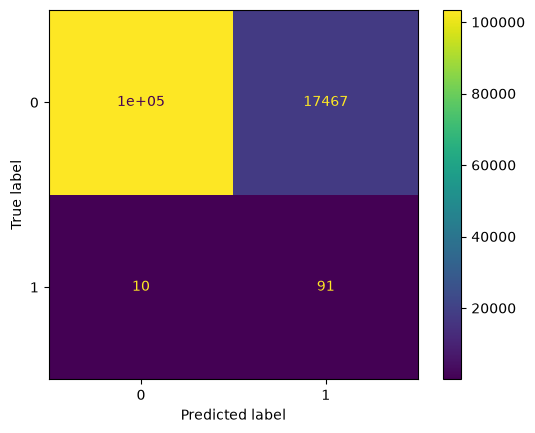

In [9]:
# confusion matrix
print(pd.crosstab(y_test, predictions_binary))
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(y_test,predictions_binary)

display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0','1'])
display_cm.plot()

plt.show()

### Diagnosing the failure
Using `decision_function` to check whether the true anomalies show up as clearly negative
scores, or whether they blend into the normal range.

What was found:
- There is a measurable difference — anomaly scores are lower on average (`0.147` vs `0.215`)
- The two distributions overlap a lot, meaning individual rows are often not distinguishable
  from one another

This suggests the model is learning something real, but the signal is weak.

In [10]:
test_df['anomaly_score'] = clf.decision_function(X_test)
print(test_df[test_df['is_anomaly'] == 1]['anomaly_score'].describe())
print(test_df[test_df['is_anomaly'] == 0]['anomaly_score'].describe())

count    101.000000
mean      -0.034483
std        0.029124
min       -0.111995
25%       -0.056119
50%       -0.031388
75%       -0.012062
max        0.021072
Name: anomaly_score, dtype: float64
count    120859.000000
mean          0.034724
std           0.032720
min          -0.128591
25%           0.020392
50%           0.043117
75%           0.058105
max           0.095971
Name: anomaly_score, dtype: float64


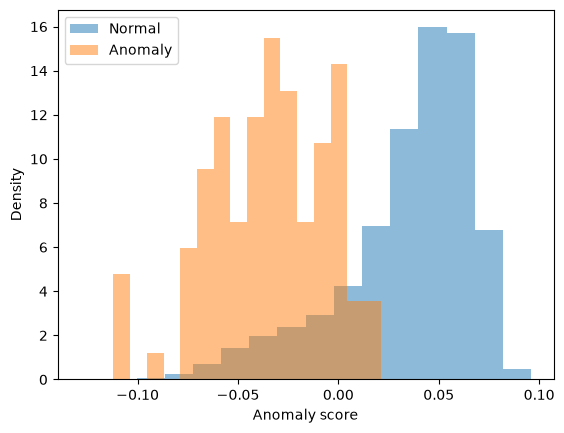

In [11]:
plt.hist(
    test_df[test_df['is_anomaly'] == 0]['anomaly_score'],
    bins=16,
    alpha=0.5,
    density=True,
    label='Normal'
)

plt.hist(
    test_df[test_df['is_anomaly'] == 1]['anomaly_score'],
    bins=16,
    alpha=0.5,
    density=True,
    label='Anomaly'
)

plt.xlabel("Anomaly score")
plt.ylabel("Density")
plt.legend()
plt.show()

In [12]:
# check the cpu_percent anomalies for web_1 are present
# confirm if that some data is missing
df[(df['server_id'] == 'web_1') & (df['is_anomaly'] == 1)]['cpu_percent'].describe()

count     25.000000
mean      92.084422
std        2.819505
min       86.672905
25%       90.864560
50%       91.608226
75%       93.547604
max      100.000000
Name: cpu_percent, dtype: float64

### Hypothesis 1: The feature set is too large. 
As isolation forest builds trees based on randomly selected features, with so many features and where only a handful of them hold a strong signal of an anomaly, there is a chance that the model is splitting on irrelevant features which don't relate to the particular anomaly.

**Next experiment**: Train the model using a smaller feature set, using only the raw values.

In [13]:
y_train_raw = normal_train_df['is_anomaly']
X_train_raw = normal_train_df[['cpu_percent','memory_percent','disk_io']]

contamination_rate_raw = y_train_raw.sum() / len(y_train_raw)
print(f'Contamination rate : {contamination_rate_raw}')

# train the model usint the new feature set
clf_raw = IsolationForest(contamination='auto', random_state=42).fit(X_train_raw)

Contamination rate : 0.0


In [14]:
y_test_raw = test_df['is_anomaly']
X_test_raw = test_df[['cpu_percent','memory_percent','disk_io']]

# Predict using the trained model
predictions_raw = clf_raw.predict(X_test_raw)
print(pd.Series(predictions_raw).value_counts())

predictions_binary_raw = (predictions_raw == -1).astype(int)

# classification report on the predicitons
classification_report_raw = classification_report(y_test_raw, predictions_binary_raw)
print(classification_report_raw)

 1    92479
-1    28481
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      0.77      0.87    120859
           1       0.00      1.00      0.01       101

    accuracy                           0.77    120960
   macro avg       0.50      0.88      0.44    120960
weighted avg       1.00      0.77      0.87    120960



#### Results
From the above experiment, it is clear even modelling on a smaller featrue set doesn't seem to imporove the model. However it has highlighted that the raw data values need to be looked into a little more.

The raw `cpu_percent` values need to be considered, for `batch_worker` server type the cpu_percent is 0 for majority of the day. This means a huge chunk of the whole dataset is sitting around 0. Isolation forest is based on random splits of randomly chosen features, the raw values are incomparable compared to other values within the dataset. Specifcially for `cpu_percent`, `web_1` server raw values can't be comapred to the `batch_worker`'s (constant 0) raw values 

### Hypothesis 2: Data heterogeneity across server types

With 5 structurally different server types (15 servers total) sharing a single Isolation
Forest, the model's notion of "normal" is being shaped by all five distributions at once —
in particular, `batch_worker`'s mostly-zero, briefly-spiking pattern appears to dominate the
overall score scale, based on the sorted anomaly-score investigation above. Including
`server_type` as a one-hot feature was an attempt to let the model condition on this
difference, but the experiments above (full feature set, reduced feature set, Z-score-only
feature set) all produced near-identical, near-zero precision/recall for the anomaly class —
suggesting the model isn't reliably learning to separate "normal" per server type from a
single shared training pass.

**Next experiment:** train 5 separate Isolation Forest models, one per `server_type`, each
learning "normal" from only its own server type's data. Evaluate each model against the
anomalies belonging to its own server type, rather than scoring all 15 servers with one
shared model and threshold.

### Server type: Web

Anomalies within the train df:
- 2025-01-10 10:00:00 - 2025-01-10 12:00:00, cpu spike

Anomalies within the test df:
- 2025-01-16 16:00:00 - 2025-01-16 16:35:00, memory spike
- 2025-01-21 04:10:00 - 2025-01-21 07:10:00, cpu drop

In [15]:
# filter down df by server_type_web
filtered_df_train_web = normal_train_df[normal_train_df['server_type_web'] == 1]

y_train_web = filtered_df_train_web['is_anomaly']
X_train_web = filtered_df_train_web[['cpu_percent','memory_percent','disk_io']]

# calculate the contamination rate 
contamination_rate_web = y_train_web.sum()/len(y_train_web)
print(f'Contamination rate for web servers:{contamination_rate_web}')
print((filtered_df_train_web['is_anomaly']).sum())

Contamination rate for web servers:0.0
0


In [16]:
# train isolation forest model on web server type
clf_web = IsolationForest(contamination='auto', random_state=42).fit(X_train_web)

In [17]:
filtered_df_test_web = test_df[test_df['server_type_web'] == 1]

y_test_web = filtered_df_test_web['is_anomaly']
X_test_web = filtered_df_test_web[['cpu_percent','memory_percent','disk_io']]
predictions_web = clf_web.predict(X_test_web)
print(pd.Series(predictions_web).value_counts())

predictions_binary_web = (predictions_web == -1).astype(int)

classification_report_web = classification_report(y_test_web, predictions_binary_web)
print(classification_report_web)

 1    18633
-1     5559
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      0.77      0.87     24147
           1       0.01      1.00      0.02        45

    accuracy                           0.77     24192
   macro avg       0.50      0.89      0.44     24192
weighted avg       1.00      0.77      0.87     24192



In [18]:
test_web = filtered_df_test_web.copy()
test_web["anomaly_score"] = clf_web.decision_function(X_test_web)

print(test_web[test_web['is_anomaly'] == 1]['anomaly_score'].describe())
print(test_web[test_web['is_anomaly'] == 0]['anomaly_score'].describe())

count    45.000000
mean     -0.111469
std       0.019049
min      -0.176831
25%      -0.121355
50%      -0.108742
75%      -0.096187
max      -0.078520
Name: anomaly_score, dtype: float64
count    24147.000000
mean         0.024035
std          0.040688
min         -0.191235
25%          0.003707
50%          0.033072
75%          0.054370
max          0.086348
Name: anomaly_score, dtype: float64


In [19]:
pd.set_option('display.max_rows', 61)

web_1 = test_web[test_web['server_id'] == 'web_1']

test_web[
    (test_web['timestamp'] >= '2025-01-21 03:10:00') &
    (test_web['timestamp'] <= '2025-01-21 08:10:00') &
    (test_web['server_id'] == 'web_2')
][[
    'timestamp',
    'cpu_percent',
    'is_anomaly',
    'cpu_percent_roll_mean_5',
    'cpu_percent_roll_mean_10',
    'cpu_percent_roll_mean_30',
    'cpu_percent_zscore_5',
    'cpu_percent_zscore_10',
    'cpu_percent_zscore_30',
    'cpu_percent_rate_of_change'
]]


,timestamp,cpu_percent,is_anomaly,cpu_percent_roll_mean_5,cpu_percent_roll_mean_10,cpu_percent_roll_mean_30,cpu_percent_zscore_5,cpu_percent_zscore_10,cpu_percent_zscore_30,cpu_percent_rate_of_change
17890,2025-01-21 03:10:00,36.031807,0,29.659019,29.799242,27.756488,3.283555,2.959991,2.835101,6.398571
17891,2025-01-21 03:15:00,26.373275,0,31.270701,30.727118,28.011760,-1.551602,-1.674307,-0.498558,-9.658531
17892,2025-01-21 03:20:00,31.739976,0,30.836472,30.238976,27.912652,0.242644,0.512656,1.163449,5.366701
17893,2025-01-21 03:25:00,30.752808,0,30.596174,30.416810,28.254396,0.043629,0.113399,0.798800,-0.987168
17894,2025-01-21 03:30:00,30.457737,0,30.906220,30.170691,28.319401,-0.127931,0.102418,0.676775,-0.295071
17895,2025-01-21 03:35:00,28.626463,0,31.071121,30.365070,28.259570,-0.708648,-0.634120,0.118392,-1.831274
17896,2025-01-21 03:40:00,29.776246,0,29.590052,30.430376,28.306758,0.087765,-0.243563,0.475069,1.149783
17897,2025-01-21 03:45:00,30.829519,0,30.270646,30.553559,28.343104,0.482155,0.105452,0.800982,1.053273
17898,2025-01-21 03:50:00,33.830995,0,30.088554,30.342364,28.574054,4.082241,1.404058,1.741350,3.001477
17899,2025-01-21 03:55:00,35.195139,0,30.704192,30.805206,28.886886,2.316692,1.642484,2.059960,1.364144


### Results

| Experiment                  | Precision |   Recall |       F1 | Interpretation                                    |
| --------------------------- | --------: | -------: | -------: | ------------------------------------------------- |
| Global, engineered features |      0.01 |     0.45 |     0.02 | Very poor; lots of false alarms / poor separation |
| Global, raw 3 features      |      0.02 |     0.91 |     0.04 | Finds anomalies, but massively over-flags         |
| Web-only, 3 CPU features    |  **0.24** | **0.69** | **0.36** | Much more promising                               |

The server specifc model performed much better 


### Hypothesis 3: Use residual features instead of rolling window features
Below is an experiment, using the `residual` and `baseline` features generated adn training isolation forest models on each individual server.


### Loading dataset

In [20]:
# loading the dataset into dataframe
residual_df = pd.read_csv('../data/features_residual.csv')

residual_df.head()

,timestamp,server_id,cpu_percent,memory_percent,disk_io,is_anomaly,anomaly_type,hour,day_of_week,cpu_percent_baseline,cpu_percent_residual,memory_percent_baseline,memory_percent_residual,disk_io_baseline,disk_io_residual,server_type_batch_worker,server_type_cache,server_type_database,server_type_load_balancer,server_type_web
0,2025-01-01 00:00:00,web_1,24.585207,33.194309,51.865857,0,normal,0,2,25.208847,-0.623640,34.838226,-1.643918,50.063459,1.802398,0,0,0,0,1
1,2025-01-01 00:05:00,web_1,26.946724,37.129782,48.890155,0,normal,0,2,25.208847,1.737876,34.838226,2.291556,50.063459,-1.173304,0,0,0,0,1
2,2025-01-01 00:10:00,web_1,29.583721,35.496424,45.627445,0,normal,0,2,25.208847,4.374873,34.838226,0.658198,50.063459,-4.436014,0,0,0,0,1
3,2025-01-01 00:15:00,web_1,24.330454,30.116072,50.508945,0,normal,0,2,25.208847,-0.878394,34.838226,-4.722154,50.063459,0.445486,0,0,0,0,1
4,2025-01-01 00:20:00,web_1,24.356086,32.283149,47.617581,0,normal,0,2,25.208847,-0.852761,34.838226,-2.555077,50.063459,-2.445878,0,0,0,0,1


In [21]:
# split df into train and test
train_residual_df = residual_df[residual_df['timestamp'] < '2025-01-15 00:00:00']
test_residual_df = residual_df[residual_df['timestamp'] >= '2025-01-15 00:00:00']

# generate a baseline df, where there are no anomalies for training the model
normal_train_residual_df = train_residual_df[train_residual_df['is_anomaly'] == 0]

print(len(train_df))
print(len(test_df))
print(len(normal_train_df))

print(train_residual_df['is_anomaly'].value_counts())
print(test_residual_df['is_anomaly'].value_counts())
print(normal_train_residual_df['is_anomaly'].value_counts())

60450
120960
60382
is_anomaly
0    60412
1       68
Name: count, dtype: int64
is_anomaly
0    120859
1       101
Name: count, dtype: int64
is_anomaly
0    60412
Name: count, dtype: int64


### Training an isolation forest model on web server
Using the default `auto` for the contamination rate, influenced the model to predict **40%** of anomalies when there are actually only **0.19%**. This was also an issue with the other experiments

Table of contamination rates and results:
| Conatmination rate          | No of anomalies detected                               
| --------------------------- | -----------------------  |
| auto                        |      40%                 | 
|                             |                          | 
|                             |                          | 


In [23]:
filtered_train_residual_df_web = normal_train_residual_df[normal_train_residual_df['server_type_web'] == 1]

y_train_residual_web = filtered_train_residual_df_web['is_anomaly']
X_train_residual_web = filtered_train_residual_df_web.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

# calculate the contamination rate 
contamination_rate_web = y_train_residual_web.sum()/len(y_train_residual_web)
print(f'Contamination rate for web servers:{contamination_rate_web}')

Contamination rate for web servers:0.0


### Finding the best contamination rate 

In [24]:
# train the model
residual_clf_web = IsolationForest(contamination='auto', random_state=42).fit(X_train_residual_web)

In [25]:
train_scores_web = residual_clf_web.decision_function(
    X_train_residual_web
)

print(pd.Series(train_scores_web).describe())

count    12071.000000
mean         0.004079
std          0.029514
min         -0.123188
25%         -0.013051
50%          0.008048
75%          0.025906
max          0.067374
dtype: float64


In [26]:
filtered_test_residual_df_web = test_residual_df[test_residual_df['server_type_web'] == 1]

y_test_residual_web = filtered_test_residual_df_web['is_anomaly']
X_test_residual_web = filtered_test_residual_df_web.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

predictions_residual_web = residual_clf_web.predict(X_test_residual_web)
print(pd.Series(predictions_residual_web).value_counts())

predictions_binary_residual_web = (predictions_residual_web == -1).astype(int)

classification_report_residual_web = classification_report(y_test_residual_web, predictions_binary_residual_web)
print(classification_report_residual_web)

 1    14567
-1     9625
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      0.60      0.75     24147
           1       0.00      1.00      0.01        45

    accuracy                           0.60     24192
   macro avg       0.50      0.80      0.38     24192
weighted avg       1.00      0.60      0.75     24192



### Hypothesis 4: Limitations of the Sythetic dataset
- The synthetic data had relatively simple distributions and noise and the server behaviour was simulated rather than based on real infrastructure workloads
- The anomaly injection was relatively artificial.
- Rolling-window features could become contaminated by sustained anomalies.
- Short windows were initially sensitive to anomaly onset but became less useful as the anomaly persisted.
- The dataset was highly imbalanced, making accuracy misleading.
- Isolation Forest sometimes classified almost everything as normal when the contamination parameter was specified.
- Results therefore shouldn't be interpreted as evidence that Isolation Forest performs poorly on infrastructure telemetry generally.

**Next step**: evaluate the same anomaly-detection pipeline on a real infrastructure telemetry dataset to determine whether the observed behaviour was primarily caused by limitations of the synthetic data or by the modelling approach itself.